# Evaluation of fine-tuned Gemini 2.0 Flash for citing sentence detection

This notebook will evaluate an instance of Gemini 2.0 Flash fine-tuned on the CiteWorth dataset.

The model has been fine-tuned by training on sentences with paragraph-level context.

In [5]:
from google import genai
from google.genai import types
import jsonlines
import concurrent.futures
from sklearn.metrics import classification_report
import time
import tqdm
import random
import threading


In [6]:
def generate(input_text):
  client = genai.Client(
      vertexai=True,
      project="438747908796",
      location="europe-west9",
  )


  model = "projects/438747908796/locations/europe-west9/endpoints/3205177550036795392"
  contents = [
    types.Content(
      role="user",
      parts=[
        types.Part(
          text=input_text
        )
      ]
    )
  ]

  generate_content_config = types.GenerateContentConfig(
    temperature = 0,
    top_p = 0.1,
    max_output_tokens = 8192,
    safety_settings = [types.SafetySetting(
      category="HARM_CATEGORY_HATE_SPEECH",
      threshold="OFF"
    ),types.SafetySetting(
      category="HARM_CATEGORY_DANGEROUS_CONTENT",
      threshold="OFF"
    ),types.SafetySetting(
      category="HARM_CATEGORY_SEXUALLY_EXPLICIT",
      threshold="OFF"
    ),types.SafetySetting(
      category="HARM_CATEGORY_HARASSMENT",
      threshold="OFF"
    )],
  )


  output = client.models.generate_content(
    model = model,
    contents = contents,
    config = generate_content_config,
    )

  return output.text


In [7]:
CITEWORTH_TEST_PATH = "C:\\Users\\Adrian\\Documents\\datasets\\citeworth-jsonl\\test.jsonl"

In [12]:
# Load the test dataset
with jsonlines.open(CITEWORTH_TEST_PATH) as reader:
    test_data = [obj for obj in reader]
    inputs = [item['contents'][0]['parts'][0]['text'] for item in test_data]
    truths = [item['contents'][1]['parts'][0]['text'] for item in test_data]

if len(inputs) != len(truths):
    raise ValueError("Inputs and truths must have the same length.")

In [13]:
# Function to process a single input with exponential backoff
def process_single_input(input_text, initial_delay=1, max_retries=5):
    retry_count = 0
    delay = initial_delay

    while retry_count <= max_retries:
        try:
            result = generate(input_text)
            # Success - return the result
            return result
        except Exception as e:
            if "429" in str(e) or "quota" in str(e).lower():
                retry_count += 1
                if retry_count <= max_retries:
                    # Exponential backoff with jitter
                    wait_time = delay * (2 ** retry_count) + random.uniform(0, 1)
                    print(f"Rate limit hit, backing off for {wait_time:.2f} seconds (retry {retry_count}/{max_retries})...")
                    time.sleep(wait_time)
                    delay = wait_time  # Update the delay for the next potential retry
                else:
                    print(f"Max retries exceeded for input, skipping")
                    return ""  # Return empty result after max retries
            else:
                print(f"Error processing input: {e}")
                print(input_text)
                retry_count += 1

    return "ERROR"  # Should not reach here, but just in case

# Function to process a batch of inputs with ThreadPoolExecutor
def process_batch_parallel(batch, initial_delay=1, max_retries=5, max_workers=8):
    # Use a rate limiter to stagger submissions to the thread pool
    def submit_with_delay(executor, fn, *args, **kwargs):
        time.sleep(random.uniform(0.1, 0.5))  # Add some randomness to prevent thundering herd
        return executor.submit(fn, *args, **kwargs)

    results = []

    # Process inputs with ThreadPoolExecutor
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks to the executor with staggered delays
        future_to_index = {
            submit_with_delay(executor, process_single_input, text, initial_delay, max_retries): i
            for i, text in enumerate(batch)
        }

        # Process futures as they complete
        for future in concurrent.futures.as_completed(future_to_index):
            index = future_to_index[future]
            try:
                result = future.result()
                # Store result at the correct index to maintain order
                results.append((index, result))
            except Exception as e:
                print(f"Task failed with error: {e}")
                results.append((index, ""))


    # Sort results by index to maintain original order
    results.sort(key=lambda x: x[0])
    return [r[1] for r in results]


In [20]:
# Set batch parameters
BATCH_SIZE = 16  # Number of inputs to process in each batch
INITIAL_DELAY = 0.1  # Initial delay between requests
MAX_RETRIES = 24   # Maximum number of retries per request
MAX_WORKERS = 12   # Maximum number of parallel workers per batch

# Process in batches with parallel execution within each batch
test_inputs = inputs  # Adjust as needed

predictions = []
labels = []

for i in tqdm.tqdm(range(0, len(test_inputs), BATCH_SIZE)):
    batch_length = min(i + BATCH_SIZE, len(test_inputs)) - i
    batch = test_inputs[i:i+batch_length]
    batch_labels = truths[i:i+batch_length]
    batch_end = min(i+BATCH_SIZE, len(test_inputs))

    # Process this batch in parallel
    batch_results = process_batch_parallel(
        batch,
        initial_delay=INITIAL_DELAY,
        max_retries=MAX_RETRIES,
        max_workers=MAX_WORKERS)
    predictions.extend(batch_results)
    labels.extend(batch_labels)

    if len(batch_results) != len(batch_labels):
        print(f"Warning: Batch {i//BATCH_SIZE + 1} produced {len(batch_results)} results, expected {len(batch_labels)}. Some results may be missing.")


100%|██████████| 1313/1313 [2:31:56<00:00,  6.94s/it] 


In [31]:
def fix_pred(pred, length):
    """
    Fix the prediction to ensure it has the correct length.
    If the prediction is shorter than the expected length, append '\nx: non-check-worthy'.
    """
    if len(pred) < length:
        return pred + ['x: non-check-worthy'] * (length - len(pred))
    if len(pred) > length:
        return pred[:length]  # Truncate if it's too long
    return pred

# Get sentences
predictions_2 = [prediction.split('\n') for prediction in predictions]
labels_2 = [label.split('\n') for label in labels]

if all(len(pred) == len(lbl) for pred, lbl in zip(predictions_2, labels_2)):
    print("All predictions and labels have the same number of lines.")
else:
    print("Warning: Predictions and labels do not have the same number of lines in some cases, padding/truncating predictions.")
    max_length = [len(lbl) for lbl in labels_2]
    predictions_2 = [fix_pred(pred, length) for pred, length in zip(predictions_2, max_length)]

predictions_2 = [item.split(": ")[1] for sublist in predictions_2 for item in sublist if item]
labels_2 = [item.split(": ")[1] for sublist in labels_2 for item in sublist if item]

# turn into True/False
predictions_2 = [prediction.lower() == 'check-worthy' for prediction in predictions_2]
labels_2 = [label.lower() == 'check-worthy' for label in labels_2]

In [32]:
# if len(predictions) != len(labels):
#     raise ValueError("Predictions and labels must have the same length.")

report = classification_report(labels_2, predictions_2)

print(report)

              precision    recall  f1-score   support

       False       0.84      0.89      0.86     80946
        True       0.72      0.63      0.67     37239

    accuracy                           0.81    118185
   macro avg       0.78      0.76      0.77    118185
weighted avg       0.80      0.81      0.80    118185



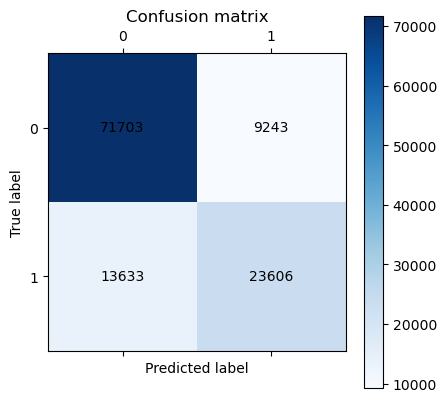

In [33]:
# confusion matrix image
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels_2, predictions_2)
# Plot the confusion matrix with numbers on squares
plt.matshow(cm, cmap=plt.cm.Blues)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(x=j, y=i, s=cm[i, j], va='center', ha='center')
plt.title("Confusion matrix")
plt.colorbar()
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

In [36]:
# Save predictions and labels to disk
import pickle

with open("../data/gemini_citeworth_results/predictions.pkl", "wb") as f:
    pickle.dump(predictions_2, f)

with open("../data/gemini_citeworth_results/labels.pkl", "wb") as f:
    pickle.dump(labels_2, f)

with open("../data/gemini_citeworth_results/raw_predictions.pkl", "wb") as f:
    pickle.dump(predictions, f)